In [1]:
# =========================
# AOEnv 测试 notebook 脚本
# =========================

import sys
import os
sys.path.append('/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO')
sys.path.append(os.path.dirname(os.getcwd()))
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt

# 导入 AOEnv
from AdaptiveOpticsEnvR2DISC import AOEnv

# 构造 args
args = SimpleNamespace(
    agent = "PPO",
    episodes = 10,
    seed = 0,
    maxStep = 500,
    gainCL = 0.6,
    samplingRate = 1000,
    exposureTime = 1,
    clockRate = 1000,
    lightRatio = 0.6,
    paramFile = "1-1",  
    k = 3,
    delay=0
)








     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
1.26.2


In [2]:
# 创建环境

env = AOEnv(args)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:10<01:21, 10.23s/it]

100/856
Time elapsed: 10.228744506835938 s


 22%|██▏       | 2/9 [00:20<01:10, 10.13s/it]

200/856
Time elapsed: 10.066730737686157 s


...

 89%|████████▉ | 8/9 [01:24<00:10, 10.77s/it]

800/856
Time elapsed: 10.896414279937744 s


100%|██████████| 9/9 [01:30<00:00, 10.05s/it]

900/856
Time elapsed: 6.008181095123291 s


No Modal Gains found. All gains set to 1


In [3]:
action = [8,9,18,9]
list(env.get_action_from_discrete(action))

[0.5, 1000.0, 1.0, 1000.0]

In [4]:
done = False
env.reset()
episode_return=0
# plt.imshow(env.camH.referenceFrame)
env.dm.coefs = 0
while not done:
        state, reward, done, info = env.step(action)
        episode_return += reward
        print("step:{} --- reward:{:.4f} SR:{:.4f}".format(env.current_step,reward,env.camH.strehl))
print("平均SR:{:.4f}".format(np.mean(env.actual_SR)))

-> Computing the initial phase screen...
initial phase screen : 0.026467323303222656 s
ZZt.. : 16.08309316635132 s
ZXt.. : 0.6930785179138184 s
XXt.. : 0.29707956314086914 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.022989273071289062 s
ZZt.. : 1.9073486328125e-06 s
ZXt.. : 3.218650817871094e-05 s
XXt.. : 7.867813110351562e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.023120403289794922 s
ZZt.. : 4.291534423828125e-06 s
ZXt.. : 3.933906555175781e-05 s
XXt.. : 8.106231689453125e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
step:1 --- reward:-0.3834 SR:0.1677
step:2 --- reward:-0.2293 SR:0.2643
step:3 --- reward:-0.0329 SR:0.4210
step:4 --- reward:0.7399 SR:0.5102
step:5 --- reward:0.7787 SR:0.5287
step:6 --- reward:0.7544 SR:0.5059
step:7 --- reward:0.7397 SR:0.4926
step:8 --- reward:0.7286 SR:0.4822
step:9 --- reward:0.7260 SR

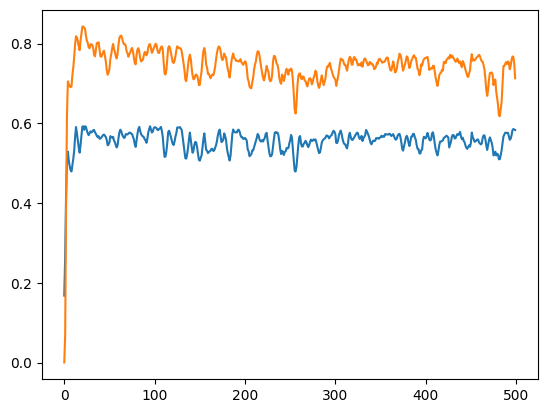

In [5]:
plt.plot(env.actual_SR)
plt.plot(env.SR_old)

In [ ]:
obs = env.reset()
list(env.get_action_from_discrete(action))
done = False
episode_return=0
# plt.imshow(env.camH.referenceFrame)
while not done:
        state, reward, done, info = env.step(action)
        episode_return += reward
        print("step:{} --- reward:{:.4f} SR:{:.4f}".format(env.current_step,reward,env.camH.strehl))
print("平均SR:{:.4f}",np.mean(env.actual_SR))

step:1 --- reward:-0.4224 SR:0.1295
step:2 --- reward:-0.3334 SR:0.1645
step:3 --- reward:-0.2035 SR:0.2540
step:4 --- reward:0.5725 SR:0.3504
step:5 --- reward:0.6511 SR:0.4009
step:6 --- reward:0.6713 SR:0.4122
step:7 --- reward:0.6754 SR:0.4133
step:8 --- reward:0.6780 SR:0.4134
step:9 --- reward:0.6836 SR:0.4156
step:10 --- reward:0.6859 SR:0.4168
step:11 --- reward:0.6866 SR:0.4169
step:12 --- reward:0.6919 SR:0.4212
step:13 --- reward:0.7044 SR:0.4319
step:14 --- reward:0.6995 SR:0.4290
step:15 --- reward:0.6911 SR:0.4234
step:16 --- reward:0.6939 SR:0.4250
step:17 --- reward:0.7003 SR:0.4292
step:18 --- reward:0.6969 SR:0.4271
step:19 --- reward:0.6904 SR:0.4231
step:20 --- reward:0.6920 SR:0.4253
step:21 --- reward:0.7014 SR:0.4341
step:22 --- reward:0.7289 SR:0.4579
step:23 --- reward:0.7472 SR:0.4735
step:24 --- reward:0.7561 SR:0.4791
step:25 --- reward:0.7562 SR:0.4754
step:26 --- reward:0.7560 SR:0.4720
step:27 --- reward:0.7566 SR:0.4706
step:28 --- reward:0.7556 SR:0.469

In [10]:
import time
import numpy as np
import os
import sys

# 将目录添加到 Python 路径
sys.path.append('/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO')
from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.ShackHartmann import ShackHartmann
from tutorials.scao_system.myAoSystem.Imager_new import Imager_new  # 导入新的科学相机模块
from tutorials.scao_system.myAoSystem.Imager import Imager # 导入之前的的科学相机模块
import matplotlib.pyplot as plt
import OOPAO.tools.displayTools as tools
from OOPAO.calibration.ao_calibration import ao_calibration

tel = Telescope(resolution         =   env.param['resolution'], 
                        diameter           =   env.param['diameter'], 
                        samplingTime       =   1/env.param['samplingRate'], 
                        centralObstruction =   env.param['centralObstruction'])

ngs = Source(magnitude             =   env.param['magnitude'],
                    optBand               =   env.param['opticalBand'])
ngs * tel
atm = Atmosphere(telescope         =   env.tel, 
                        r0                =   env.param['r0'], 
                        L0                =   env.param['L0'], 
                        windSpeed         =   env.param['windSpeed'],
                        fractionalR0      =   env.param['fractionnalR0'], 
                        windDirection     =   env.param['windDirection'],
                        altitude          =   env.param['altitude'])

dm = DeformableMirror(telescope    =   env.tel, 
                            nSubap       =   env.param['nSubap'], 
                            mechCoupling =   env.param['mechCoupling'])

wfs = ShackHartmann(nSubap         =   env.param['nSubap'], 
                            telescope      =   env.tel, 
                            lightRatio     =   env.param['lightRatio'], 
                            is_geometric   =   env.param['is_geometric'], 
                            threshold_cog  =   env.param['threshold_cog'])


camH = Imager(exposure_time=env.param['exposureTime'], 
                    clock_rate=env.param['clockRate'],
                    nyquist_sampling=env.param['nyquist_sampling'],
                    field_stop_size=env.param['field_stop_size'])



%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    5.5e-07     0        0        inf       -0.0   8967391304.3
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

In [ ]:
ao_calib = ao_calibration(param=env.param, \
                            ngs=env.ngs, \
                            tel=env.tel, \
                            atm=env.atm, \
                            dm=env.dm, \
                            wfs=env.wfs, \
                            nameFolderIntMat=None, \
                            nameIntMat=None, \
                            nameFolderBasis=None, \
                            nameBasis=None, \
                            nMeasurements=100)
calib_CL = ao_calib.calib  # 交互矩阵
M2C_CL = ao_calib.M2C
wfs.cam.photonNoise                =   env.param['photonNoise']
wfs.cam.readoutNoise               =   env.param['readoutNoise']
wfs.cam.darkCurrent                =   env.param['darkCurrent']

Loading the KL Modal Basis from: data_calibration/M2C_192_res
ERROR: No file found! Taking a zonal basis instead..
Loading Interaction matrix data_calibration/VLT_V_band_32x32/zonal_interaction_matrix_192_res_772_subap_diffractive...
ERROR: No file found! computing imat..
Interaction Matrix Computation:


 11%|█         | 1/9 [00:11<01:29, 11.24s/it]

100/856
Time elapsed: 11.23888373374939 s


 22%|██▏       | 2/9 [00:21<01:16, 10.88s/it]

200/856
Time elapsed: 10.632305383682251 s


...

500/856
Time elapsed: 9.15308928489685 s


 67%|██████▋   | 6/9 [01:02<00:30, 10.00s/it]

600/856
Time elapsed: 9.837490558624268 s


 78%|███████▊  | 7/9 [01:11<00:19,  9.91s/it]

700/856
Time elapsed: 9.708131313323975 s


In [ ]:
def run(frames=10):
    from collections import deque
    atm.initializeAtmosphere(telescope=tel)
    tel-atm
    ngs * tel * dm * wfs
    camH.relay(tel.src)
    camH.reference_frame = camH.frame
    gainCL=0.5
    actual_SR  = np.zeros(frames)
    SR_old = np.zeros(frames)
    wfs_buffer = deque([np.zeros(wfs.nSignal)] * (env.param['delay']+1), maxlen=env.param['delay']+1)
    dm.coefs = 0
    wfsSignal = np.zeros(wfs.nSignal)
    for current_step in range(frames):
        # 更新大气湍流相位屏
        atm.update()
        tel-atm
        camH.relay(tel.src)
        camH.reference_frame = camH.frame
        tel+atm

        # 光波传播：自然引导星 -> 望远镜 -> 变形镜 -> 波前传感器
        ngs * tel * dm * wfs

        wfsSignal = wfs.signal.copy()
        # # 存入队列
        # wfs_buffer.append(wfsSignal)

        # # 取出延迟后的信号
        # delayed_signal = wfs_buffer[0]
        # # 更新变形镜控制信号
        # dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ delayed_signal
        dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ wfsSignal

        # # 光波传播：自然引导星 -> 望远镜 -> 变形镜 -> 科学相机

        camH.relay(tel.src)
        SR_old[current_step]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))
        # 计算斯特列尔比（基于科学相机的PSF）
        actual_SR[current_step] = camH.strehl

        print("step:{} ---  SR:{:.4f} ----SR_old:{:.4f}".format(current_step,camH.strehl,SR_old[current_step]))
    print("平均SR:{:.4f}".format(np.mean(actual_SR)))

In [ ]:
run(500)

-> Computing the initial phase screen...
initial phase screen : 0.04255509376525879 s
ZZt.. : 17.303885459899902 s
ZXt.. : 0.6912956237792969 s
XXt.. : 0.3122546672821045 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.027745485305786133 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 4.458427429199219e-05 s
XXt.. : 1.0967254638671875e-05 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.021865367889404297 s
ZZt.. : 2.384185791015625e-07 s
ZXt.. : 2.7418136596679688e-05 s
XXt.. : 7.152557373046875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
step:0 ---  SR:0.1310 ----SR_old:0.0000
step:1 ---  SR:0.2773 ----SR_old:0.1472
step:2 ---  SR:0.4014 ----SR_old:0.5064
step:3 ---  SR:0.3815 ----SR_old:0.5029
step:4 ---  SR:0.3772 ----SR_old:0.5053
step:5 ---  SR:0.3637 ----SR_old:0.4825
step:6 ---  SR:0.3743 ----SR_old:0.5224
step:7 ---  SR:0.3885 ----SR

In [61]:
wfs.cam.readoutNoise

1

In [62]:
run(10)

step:0 ---  SR:0.2305 ----SR_old:0.0000
step:1 ---  SR:0.5449 ----SR_old:0.2283
step:2 ---  SR:0.7390 ----SR_old:0.6441
step:3 ---  SR:0.7548 ----SR_old:0.7216
step:4 ---  SR:0.7566 ----SR_old:0.7375
step:5 ---  SR:0.7613 ----SR_old:0.7355
step:6 ---  SR:0.7697 ----SR_old:0.7598
step:7 ---  SR:0.7677 ----SR_old:0.7674
step:8 ---  SR:0.7710 ----SR_old:0.7713
step:9 ---  SR:0.7680 ----SR_old:0.7687
平均SR:0.6863


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 记录所有 gain 下的平均 SR
average_SR_list = []
return_list = []
# 扫描所有 gain index
for gain_index in range(env.gain_dim):
    obs = env.reset()
    episode_return = 0
    done = False

    # 构造动作
    action = [gain_index, 9,8,9]  

    while not done:
        state, reward, done, info = env.step(action)
        episode_return += reward

    # 计算当前 gain 下平均 SR
    avg_SR = np.mean(env.actual_SR)
    average_SR_list.append(avg_SR)
    return_list.append(episode_return)

    # 如果需要，打印每次结果
    print(f"Gain index {gain_index}, gain value {env.gain_values[gain_index]:.2f}, Average SR: {avg_SR:.4f},episode_return: {episode_return:.2f}")





Gain index 0, gain value 0.10, Average SR: 0.0205,episode_return: -84.30
Gain index 1, gain value 0.15, Average SR: 0.0248,episode_return: -77.59
Gain index 2, gain value 0.20, Average SR: 0.0368,episode_return: -68.75


KeyboardInterrupt: 

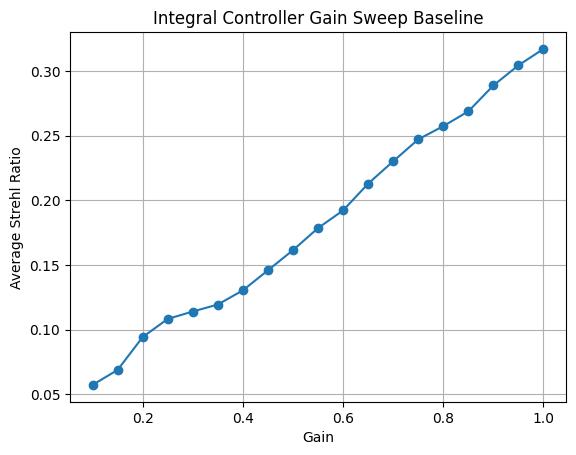

In [5]:
plt.figure()
plt.plot(env.gain_values, average_SR_list, marker='o')
plt.xlabel('Gain')
plt.ylabel('Average Strehl Ratio')
plt.title('Integral Controller Gain Sweep Baseline')
plt.grid()
plt.show()


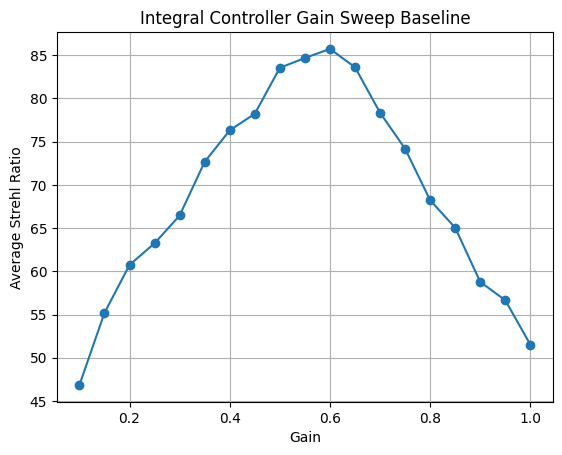

In [7]:
plt.figure()
plt.plot(env.gain_values, return_list, marker='o')
plt.xlabel('Gain')
plt.ylabel('Average Strehl Ratio')
plt.title('Integral Controller Gain Sweep Baseline')
plt.grid()
plt.show()

In [8]:
args2 = SimpleNamespace(
    agent = "PPO",
    episodes = 10,
    seed = 0,
    maxStep = 200,
    gainCL = 0.6,
    samplingRate = 1000,
    exposureTime = 1,
    clockRate = 1000,
    lightRatio = 0.3,
    paramFile = "paramFile1",  
    k = 3,
    delay=0
)
env2 = AOEnv(args2)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       5.0    29891304.3
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates load

 25%|██▌       | 1/4 [00:03<00:09,  3.27s/it]

100/357
Time elapsed: 3.2724649906158447 s


 50%|█████     | 2/4 [00:06<00:06,  3.10s/it]

200/357
Time elapsed: 2.975788116455078 s


 50%|█████     | 2/4 [00:08<00:08,  4.46s/it]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 记录所有 gain 下的平均 SR
average_SR_list2 = []
return_list2 = []
# 扫描所有 gain index
for gain_index in range(env2.gain_dim):
    obs = env2.reset()
    episode_return = 0
    done = False

    # 构造动作
    action = [gain_index, 4,8,9]  # gain index, sampling_rate=1000Hz, exposure=1.0, clock_rate=1000Hz

    while not done:
        state, reward, done, info = env2.step(action)
        episode_return += reward

    # 计算当前 gain 下平均 SR
    avg_SR = np.mean(env2.SR)
    average_SR_list2.append(avg_SR)
    return_list2.append(episode_return)

    # 如果需要，打印每次结果
    print(f"Gain index {gain_index}, gain value {env2.gain_values[gain_index]:.2f}, Average SR: {avg_SR:.4f}")





-> Computing the initial phase screen...
initial phase screen : 0.006682395935058594 s
ZZt.. : 1.3549654483795166 s
ZXt.. : 0.17731428146362305 s
XXt.. : 0.09280943870544434 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.006648063659667969 s
ZZt.. : 2.384185791015625e-07 s
ZXt.. : 1.7642974853515625e-05 s
XXt.. : 6.4373016357421875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.0059511661529541016 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 1.5020370483398438e-05 s
XXt.. : 6.4373016357421875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
Gain index 0, gain value 0.10, Average SR: 0.6515
Gain index 1, gain value 0.15, Average SR: 0.6855
Gain index 2, gain value 0.20, Average SR: 0.7014
Gain index 3, gain value 0.25, Average SR: 0.7079
Gain index 4, gain value 0.30, Average SR: 0.7110
Gain index 5, gain value 0.35, Average SR: 0.7153
Ga

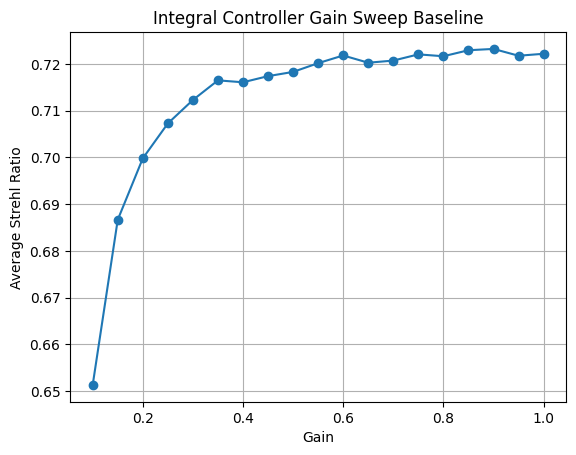

In [ ]:
plt.figure()
plt.plot(env2.gain_values, average_SR_list2, marker='o')
plt.xlabel('Gain')
plt.ylabel('Average Strehl Ratio')
plt.title('Integral Controller Gain Sweep Baseline')
plt.grid()
plt.show()

In [ ]:
import json
import matplotlib.pyplot as plt

# 读取文件
file_path = "/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir/AO1_R2DISC_lightRatio0.6_delay0_no_noise/metrics.jsonl"  # 换成你的文件路径
def draw(path, average_return):
    steps = []
    train_returns = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                record = json.loads(line.strip())
            except json.JSONDecodeError:
                continue
            if "train_return" in record:
                steps.append(record["step"])
                train_returns.append(record["train_return"])

    # 假设这是传统积分器的平均 return
    baseline_return = average_return   # <== 换成你实际的平均值

    # 画曲线
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_returns, color="tab:blue", linewidth=2, label="train_return")

    # 画虚线 (baseline)
    plt.axhline(y=baseline_return, color="tab:orange", linestyle="--", linewidth=2, label="Integrator Avg Return")

    plt.xlabel("Step")
    plt.ylabel("Train Return")
    # plt.title("Training Return Curve with Baseline")
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.show()

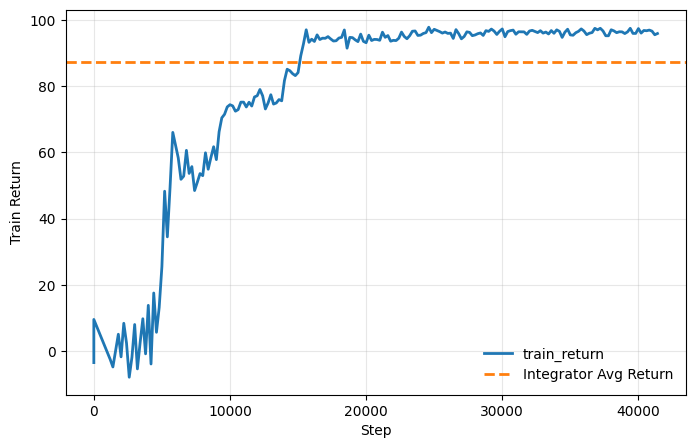

In [ ]:
draw(file_path,max(return_list))

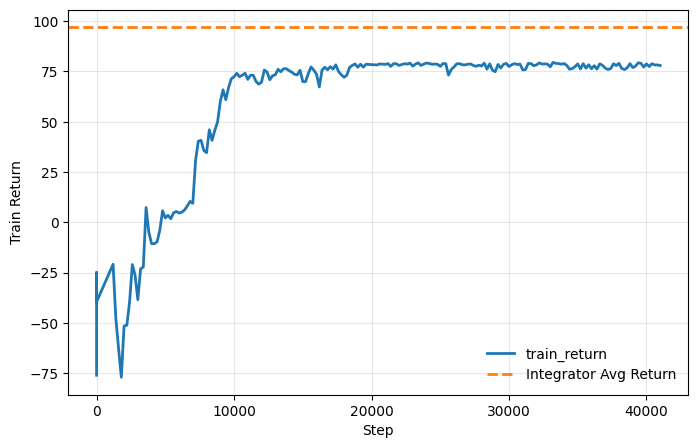

In [ ]:
file_path2 = '/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir/AO1_R2DISC_lightRatio0.6_delay2_with_noise/metrics.jsonl'
draw(file_path2,max(return_list2))

# 添加baseline

In [ ]:
import os
import shutil
from torch.utils.tensorboard import SummaryWriter

def add_tensorboard_baseline(
    log_dir_root: str, 
    baseline_tag: str, 
    baseline_value: float, 
    max_steps: int, 
    log_frequency: int = 100
):
    """
    将固定的 Baseline 值作为一条水平曲线添加到 TensorBoard 日志中。

    Args:
        log_dir_root: 您的所有 TensorBoard 日志文件的根目录（例如 'runs'）。
        baseline_tag: Baseline 曲线的名称，应与您的训练指标名称具有相同的父级分组
                      （例如，训练指标是 'Loss/Validation'，这里可以是 'Loss/Baseline'）。
        baseline_value: 传统方法 Baseline 的固定数值。
        max_steps: 训练数据中最大的 global_step 值，用于确定 Baseline 曲线的长度。
        log_frequency: 每隔多少步记录一次 Baseline 值，以覆盖 X 轴（默认 100）。
    """
    
    # 1. 确定 Baseline 日志的路径
    # 使用 'baseline' 作为子文件夹名称，以确保其作为一个独立的 Run 显示。
    baseline_log_dir = os.path.join(log_dir_root, 'baseline_reference')
    
    # 2. 清理旧的 Baseline 文件 (可选，但推荐)
    if os.path.exists(baseline_log_dir):
        print(f"检测到旧的 Baseline 文件夹，正在删除：{baseline_log_dir}")
        shutil.rmtree(baseline_log_dir)

    # 3. 创建 SummaryWriter
    print(f"正在为 Baseline 写入日志到：{baseline_log_dir}")
    writer = SummaryWriter(baseline_log_dir)

    # 4. 循环写入 Baseline 值
    # 确保循环的步数从 0 覆盖到 max_steps
    for step in range(0, max_steps + log_frequency, log_frequency):
        # 核心：使用 add_scalar 记录，值保持不变，step 持续增加
        writer.add_scalar(baseline_tag, baseline_value, step)

    writer.close()
    print("Baseline 日志写入完成。")

# ----------------------------------------------------------------------
# 示例使用
# ----------------------------------------------------------------------

# 假设您的文件结构如下：
# 根目录/
# ├── my_training_log_1/
# └── my_training_log_2/

# 假设您的训练数据中：
# 1. 记录的指标名称是 'Reward/Final'
# 2. 最大的训练步数 (global_step) 是 9800

# 调用函数
try:
    add_tensorboard_baseline(
        log_dir_root='/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir',             # 您的日志文件所在的根目录
        baseline_tag='scalars/train_return', # 曲线名称
        baseline_value=93.8268,             # 传统方法的奖励值
        max_steps=40800                 # 确保覆盖所有训练步数
    )
    print("\n---")
    print("下一步：运行 TensorBoard 命令：")
    print("tensorboard --logdir runs")
    print("然后在 SCALARS 页面查看 'Reward' 图表，它将包含一条恒定的横线。")
    
except Exception as e:
    print(f"\n执行 Baseline 写入时发生错误：{e}")

检测到旧的 Baseline 文件夹，正在删除：/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir/baseline_reference
正在为 Baseline 写入日志到：/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir/baseline_reference
Baseline 日志写入完成。

---
下一步：运行 TensorBoard 命令：
tensorboard --logdir runs
然后在 SCALARS 页面查看 'Reward' 图表，它将包含一条恒定的横线。


Gain index 0, gain value 0.10, Average SR: 0.6528
Gain index 1, gain value 0.15, Average SR: 0.6888
Gain index 2, gain value 0.20, Average SR: 0.7029
Gain index 3, gain value 0.25, Average SR: 0.7084
Gain index 4, gain value 0.30, Average SR: 0.7071
Gain index 5, gain value 0.35, Average SR: 0.7040
Gain index 6, gain value 0.40, Average SR: 0.6964
Gain index 7, gain value 0.45, Average SR: 0.6870


KeyboardInterrupt: 

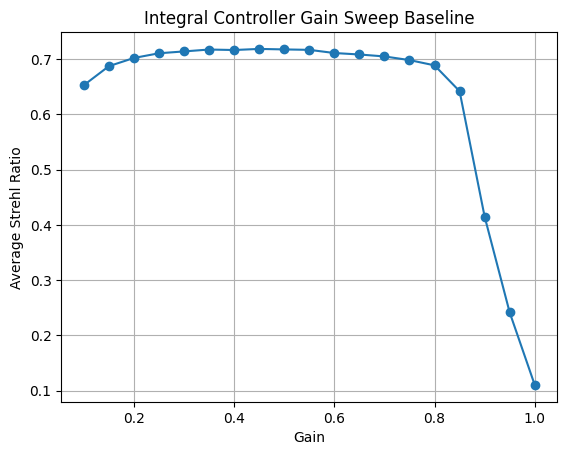

In [ ]:
# 绘制 gain vs average SR 曲线


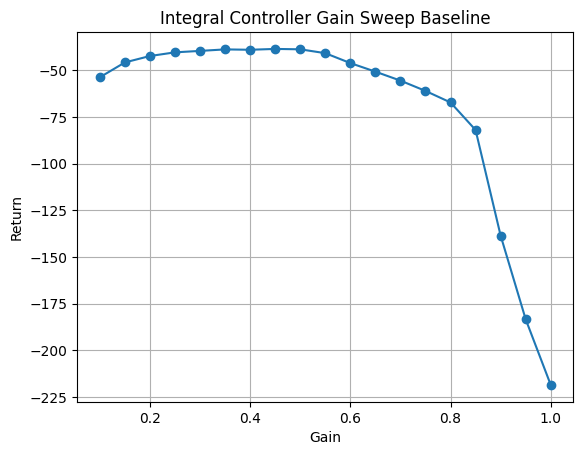

In [ ]:
plt.figure()
plt.plot(env.gain_values, return_list, marker='o')
plt.xlabel('Gain')
plt.ylabel('Return')
plt.title('Integral Controller Gain Sweep Baseline')
plt.grid()
plt.show()